Size 3x3 finished.
Size 6x6 finished.
Size 12x12 finished.
Size 24x24 finished.
Size 48x48 finished.
Size 96x96 finished.
Size 192x192 finished.
Size 384x384 finished.


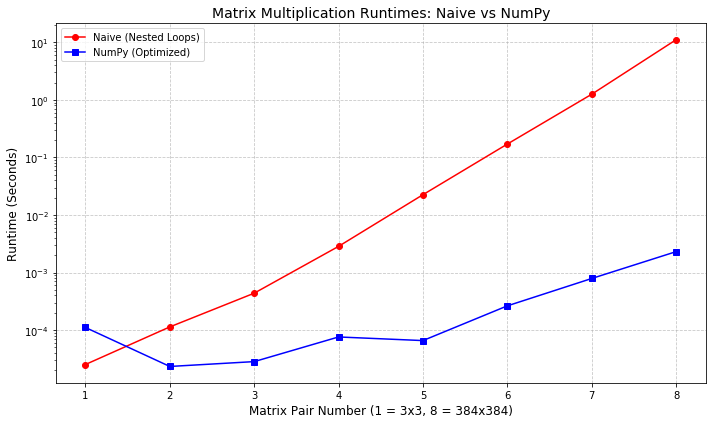

In [7]:
import numpy as np
import time
import matplotlib.pyplot as plt

# 1. Define the naive matrix multiplication function
def naive_matmul(A, B):
    # Determine the dimensions
    rows_A = len(A)
    cols_A = len(A[0])
    cols_B = len(B[0])
    
    # Initialize the result matrix C with zeros
    C = [[0 for _ in range(cols_B)] for _ in range(rows_A)]
    
    # Perform standard row-by-column multiplication
    for i in range(rows_A):
        for j in range(cols_B):
            for k in range(cols_A):
                C[i][j] += A[i][k] * B[k][j]
                
    return C

# 2. Set up the matrix sizes (3x3, 6x6, 12x12, ..., multiplying by 2 each time)
# This generates [3, 6, 12, 24, 48, 96, 192, 384]
sizes = [3 * (2**i) for i in range(8)]
matrix_numbers = list(range(1, 9))

# Lists to store the execution times
naive_times = []
numpy_times = []



# 3. Generate matrices and measure runtimes
for n in sizes:
    # Build random matrices
    A_np = np.random.rand(n, n)
    B_np = np.random.rand(n, n)
    
    # Convert to standard Python lists for a fair "naive" test 
    # (Iterating over raw numpy arrays in pure Python loops is artificially slow)
    A_list = A_np.tolist()
    B_list = B_np.tolist()
    
    # Time the Naive Method
    start_time = time.time()
    naive_matmul(A_list, B_list)
    end_time = time.time()
    naive_times.append(end_time - start_time)
    
    # Time the NumPy Method
    start_time = time.time()
    result_numpy = A_np @ B_np  # NumPy's optimized matrix multiplication
    end_time = time.time()
    numpy_times.append(end_time - start_time)
    
    print(f"Size {n}x{n} finished.")

# 4. Plot the results
plt.figure(figsize=(10, 6))

# Plotting both lines
plt.plot(matrix_numbers, naive_times, marker='o', color='red', label='Naive (Nested Loops)')
plt.plot(matrix_numbers, numpy_times, marker='s', color='blue', label='NumPy (Optimized)')

# Formatting the plot
plt.title('Matrix Multiplication Runtimes: Naive vs NumPy', fontsize=14)
plt.xlabel('Matrix Pair Number (1 = 3x3, 8 = 384x384)', fontsize=12)
plt.ylabel('Runtime (Seconds)', fontsize=12)
plt.xticks(matrix_numbers)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

# Note: We use a logarithmic scale for the y-axis because the naive time grows 
# exponentially faster than NumPy, which would make the NumPy line look completely flat at 0.
plt.yscale('log') 

plt.tight_layout()
plt.show()